In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
df = pd.read_csv("retail_sales_dataset.csv")   
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100


In [13]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,16-05-2023,CUST996,Male,62,Clothing,1,50,50
996,997,17-11-2023,CUST997,Male,52,Beauty,3,30,90
997,998,29-10-2023,CUST998,Female,23,Beauty,4,25,100
998,999,05-12-2023,CUST999,Female,36,Electronics,3,50,150
999,1000,12-04-2023,CUST1000,Male,47,Electronics,4,30,120


In [14]:
df.shape

(1000, 9)

In [15]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [17]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [18]:
df.fillna(0, inplace=True)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,24-11-2023,CUST001,Male,34,Beauty,3,50,150
1,2,27-02-2023,CUST002,Female,26,Clothing,2,500,1000
2,3,13-01-2023,CUST003,Male,50,Electronics,1,30,30
3,4,21-05-2023,CUST004,Male,37,Clothing,1,500,500
4,5,06-05-2023,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,16-05-2023,CUST996,Male,62,Clothing,1,50,50
996,997,17-11-2023,CUST997,Male,52,Beauty,3,30,90
997,998,29-10-2023,CUST998,Female,23,Beauty,4,25,100
998,999,05-12-2023,CUST999,Female,36,Electronics,3,50,150


In [19]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [28]:
df["Total Amount"].mean()


np.float64(456.0)

In [29]:
df["Total Amount"].median()


np.float64(135.0)

In [30]:
df["Total Amount"].std()

np.float64(559.997631555123)

In [36]:
df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

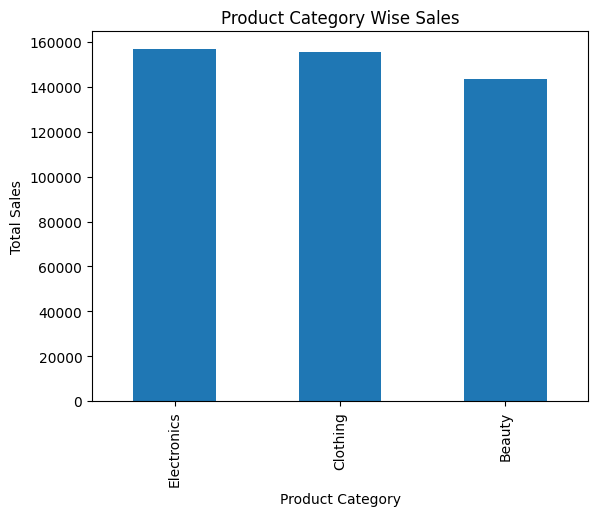

In [39]:
import matplotlib.pyplot as plt

product_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar")
plt.title("Product Category Wise Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.show()

In [44]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

In [45]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()
monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

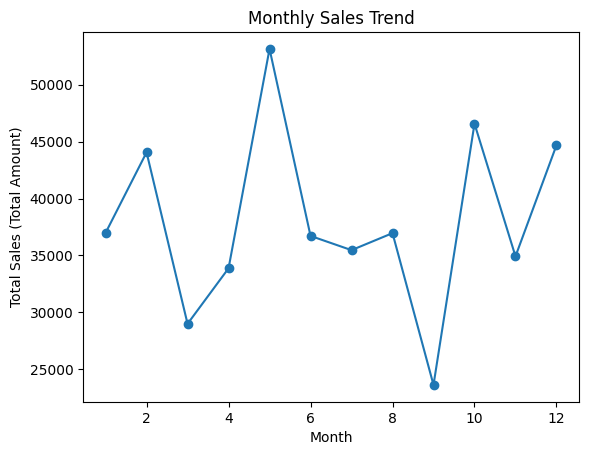

In [46]:
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (Total Amount)")
plt.show()

In [49]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()
gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

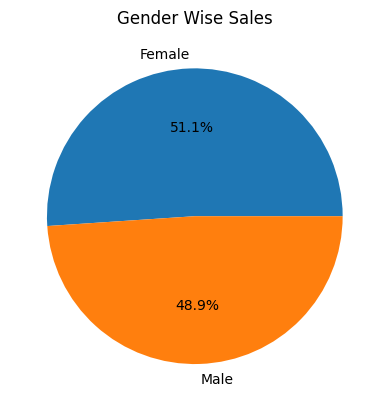

In [50]:
gender_sales.plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Wise Sales")
plt.ylabel("")
plt.show()

In [51]:
bins = [0, 18, 30, 45, 60, 100]
labels = ["Teen", "Young Adult", "Adult", "Middle Age", "Senior"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

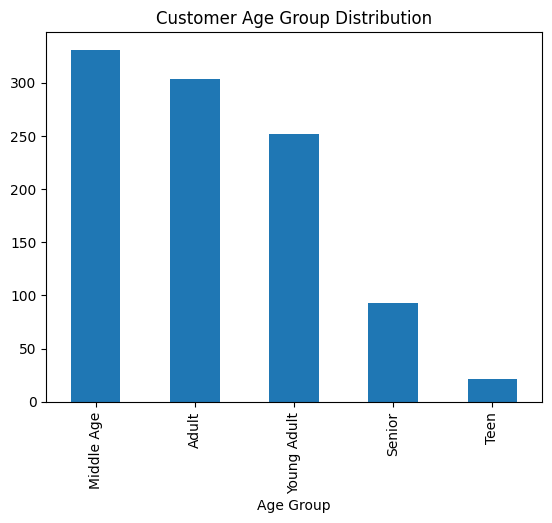

In [52]:
df["Age Group"].value_counts().plot(kind="bar")
plt.title("Customer Age Group Distribution")
plt.show()

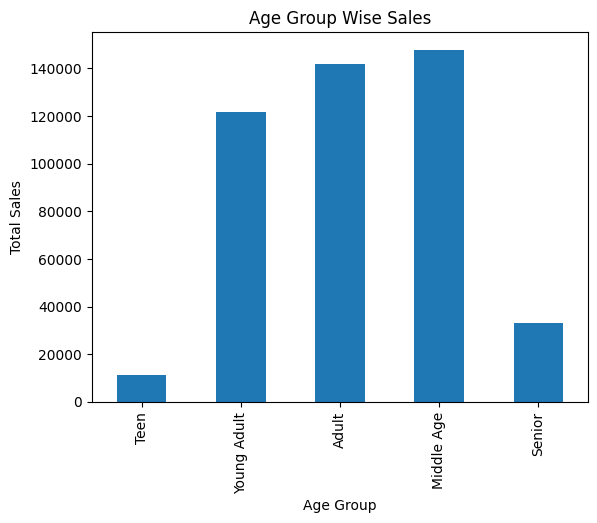

In [53]:
age_sales = df.groupby("Age Group")["Total Amount"].sum()
age_sales.plot(kind="bar")
plt.title("Age Group Wise Sales")
plt.ylabel("Total Sales")
plt.show()

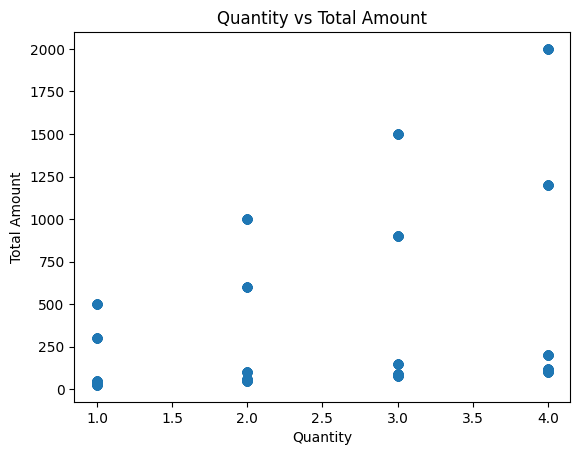

In [54]:
plt.scatter(df["Quantity"], df["Total Amount"])
plt.title("Quantity vs Total Amount")
plt.xlabel("Quantity")
plt.ylabel("Total Amount")
plt.show()

In [56]:
top_customers = df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
Name: Total Amount, dtype: int64

In [57]:
df["Total Amount"].mean()
df["Total Amount"].median()
df["Total Amount"].mode()
df["Total Amount"].std()

np.float64(559.997631555123)

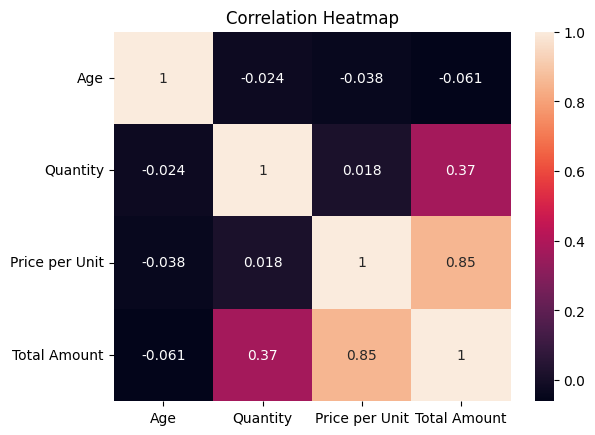

In [59]:
numeric_df = df[["Age", "Quantity", "Price per Unit", "Total Amount"]]

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

Recommendations

1. Keep more stock in May because sales are highest in this month.
2. Focus on Electronics and Clothing because these categories earn the most money.
3. Give offers to female customers because they spend a little more than males.
4. Target the 45–60 age group because they buy the most.
5. Give discounts in March and September because sales are low in these months.
6. Use “Buy More, Save More” offers because when people buy more quantity, the total amount increases.

Conclusion 

1. The best-selling categories are Electronics and Clothing.
2. The month with the highest sales is May.
3. Female customers and middle-age customers (45–60) spend the most.
4. The data is clean and complete with no missing values.
5. Sales are steady through the year with a few ups and downs.